In [1]:
import os
import pandas as pd
import random
from PIL import Image
# asdfsdfsd
data = []
path = "/root/jastudillo/Trabajo/Text_oritation/SROIE_2019_text_recognition"

for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith(".jpg"):
            file_path = os.path.join(root, file)
            angle = random.randint(-180, 180)
            img = Image.open(file_path).convert("RGB").rotate(angle, expand=True)
            data.append({"path": file_path, "filename": file, "angle": angle, "imagen":img})
df = pd.DataFrame(data)


In [2]:
df_sample = df.sample(frac=0.7,random_state=42).reset_index(drop=True)  # Shuffle the DataFrame
print(df_sample.head())
print("Total images:", len(df_sample))

                                                path  \
0  /root/jastudillo/Trabajo/Text_oritation/SROIE_...   
1  /root/jastudillo/Trabajo/Text_oritation/SROIE_...   
2  /root/jastudillo/Trabajo/Text_oritation/SROIE_...   
3  /root/jastudillo/Trabajo/Text_oritation/SROIE_...   
4  /root/jastudillo/Trabajo/Text_oritation/SROIE_...   

                                   filename  angle  \
0  0e9aa9f3-2155-4c8b-adac-992b5fe25b4e.jpg     95   
1  0ca496ee-8228-4fcc-851c-0fc35596342d.jpg    172   
2  fd3ae992-7bfb-4c8d-ab14-8ee3a2f1f72e.jpg   -151   
3  a411a47e-77b6-442e-9044-f3d830698bba.jpg    130   
4  c674e8b6-6543-470f-9a67-0918014ecf28.jpg    -60   

                                              imagen  
0  <PIL.Image.Image image mode=RGB size=54x100 at...  
1  <PIL.Image.Image image mode=RGB size=526x134 a...  
2  <PIL.Image.Image image mode=RGB size=48x43 at ...  
3  <PIL.Image.Image image mode=RGB size=675x781 a...  
4  <PIL.Image.Image image mode=RGB size=148x218 a...  
Total im

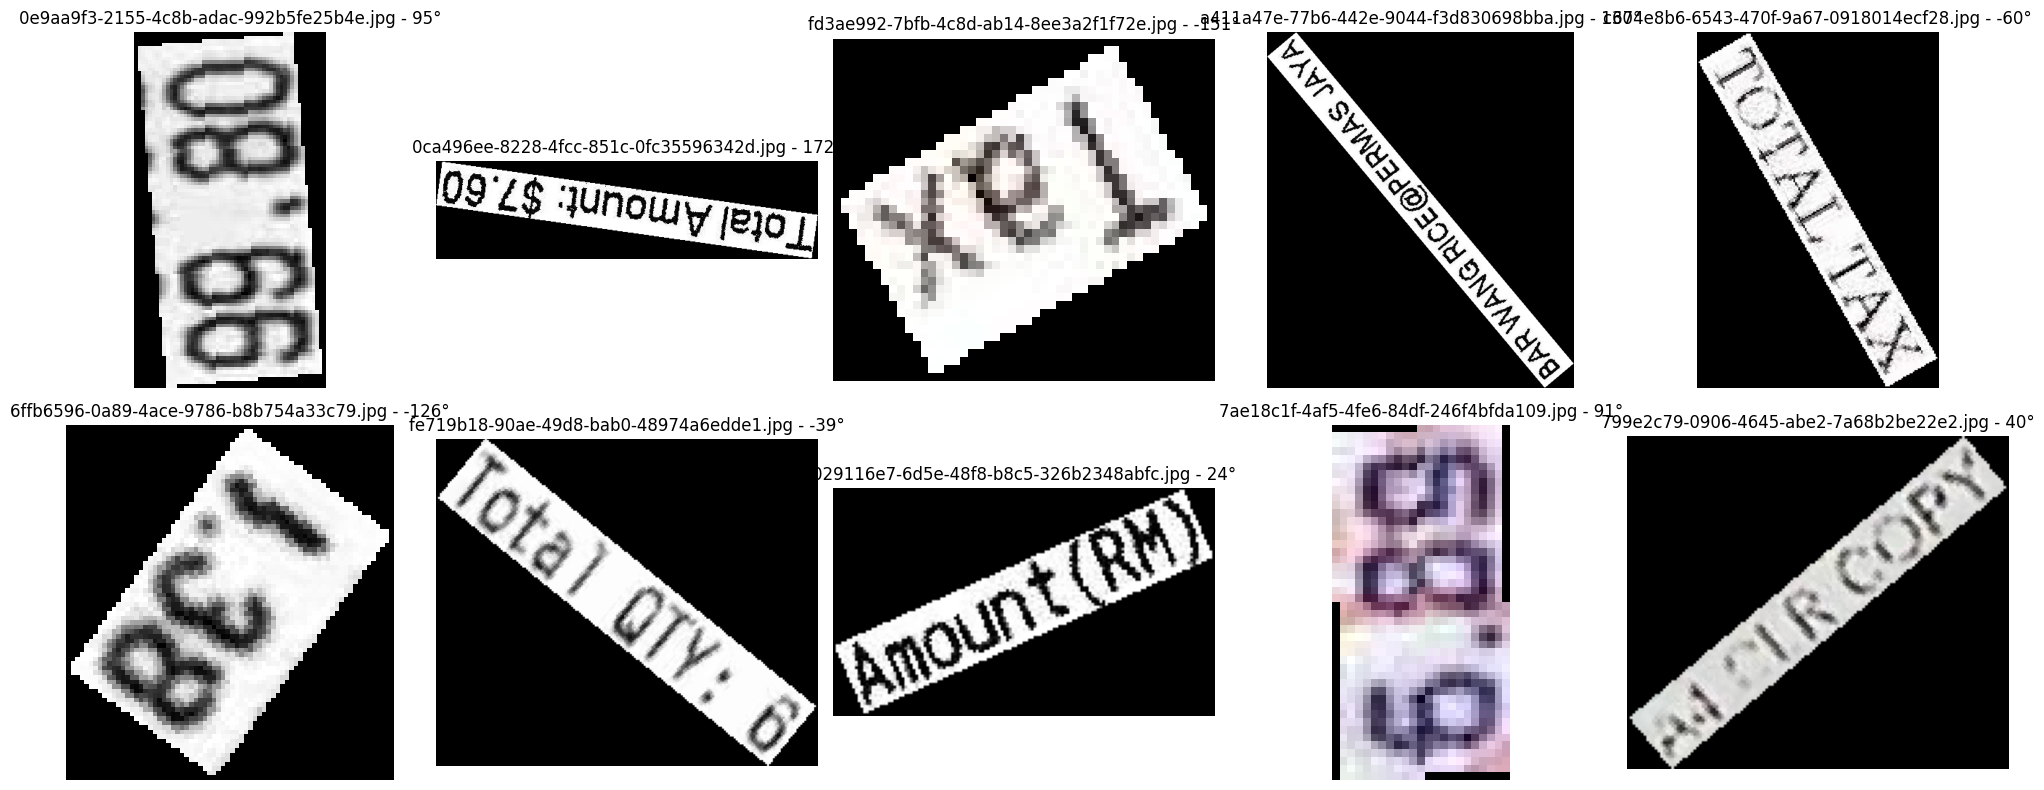

In [3]:
import matplotlib.pyplot as plt

df_show = df.sample(n=10, random_state=42)  # o usa frac=0.1
#df_sample = df_show
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for ax, (_, row) in zip(axes.flatten(), df_show.iterrows()):
    ax.imshow(row['imagen'], cmap='gray')
    ax.set_title(f"{row['filename']} - {row['angle']}°")
    ax.axis('off')

plt.tight_layout()
plt.show()


In [4]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset
import lightning as L
from sklearn.model_selection import train_test_split, KFold
from torchvision import transforms
import numpy as np

class ImageKitAngleDataset(Dataset):
    def __init__(self, images, angles):
        self.images = images
        self.angles = angles  # en grados
        self.transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            ),
        ])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]
        angle_deg = self.angles[idx]
        img_tensor = self.transform(img)
        angle_rad = np.deg2rad(angle_deg)
        return img_tensor, angle_rad


class MyDataModule(L.LightningDataModule):
    def __init__(self, df, batch_size=64, kfold=5):
        super().__init__()
        self.df = df.reset_index(drop=True)
        self.batch_size = batch_size
        self.kfold = kfold
        self.images = df["imagen"].tolist()
        self.angles = df["angle"].values.astype(np.float32)

    def prepare_data(self):
        idx = np.arange(len(self.df))
        y = self.angles
        self.X_train_idx, self.X_test_idx, self.y_train, self.y_test = train_test_split(
            idx, y, test_size=0.3, shuffle=True, random_state=42
        )
        self.kfolder = list(KFold(n_splits=self.kfold, shuffle=True, random_state=42).split(self.X_train_idx))

    def setup(self, stage=None, n_fold=0):
        if stage == "fit" or stage is None:
            train_idx, val_idx = self.kfolder[n_fold]
            train_idx = self.X_train_idx[train_idx]
            val_idx = self.X_train_idx[val_idx]
            self.train_dataset = ImageKitAngleDataset([self.images[i] for i in train_idx],
                                                      self.angles[train_idx])
            self.val_dataset = ImageKitAngleDataset([self.images[i] for i in val_idx],
                                                    self.angles[val_idx])

        if stage == "test" or stage is None:
            self.test_dataset = ImageKitAngleDataset([self.images[i] for i in self.X_test_idx],
                                                     self.angles[self.X_test_idx])

        if stage == "predict" or stage is None:
            self.predict_dataset = self.test_dataset

    def train_dataloader(self):
        return DataLoader(self.train_dataset, batch_size=self.batch_size, shuffle=True, num_workers=4)

    def val_dataloader(self):
        return DataLoader(self.val_dataset, batch_size=self.batch_size, shuffle=False, num_workers=4)

    def test_dataloader(self):
        return DataLoader(self.test_dataset, batch_size=self.batch_size, shuffle=False, num_workers=4)

    def predict_dataloader(self, data=None):
        if data is None:
            return DataLoader(self.predict_dataset, batch_size=self.batch_size, shuffle=False, num_workers=4)
        else:
            return DataLoader(data, batch_size=self.batch_size, shuffle=False, num_workers=4)


In [5]:
dataset=MyDataModule(df=df_sample,batch_size=64,kfold=5)
dataset.prepare_data()
dataset.setup()


In [6]:
print("Train dataset size:", len(dataset.images))

Train dataset size: 36631


In [7]:

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
import lightning as L
import math


# ------------------------------
# 📐 Función de pérdida angular
# ------------------------------
def angular_loss(pred, target):
    """
    Calcula la pérdida angular mínima entre dos ángulos en radianes
    Ambos deben estar en el rango [0, 2π)
    """
    diff = torch.remainder(pred - target + math.pi, 2 * math.pi) - math.pi
    return torch.mean(diff**2)


def cosine_angular_loss(pred, target):
    """
    Pérdida basada en el coseno de la diferencia angular
    """
    return 1 - torch.mean(torch.cos(pred - target))


def vector_angle_loss(pred, target):
    """
    MSE entre los vectores [sin(θ), cos(θ)] de predicho y real
    """
    pred = pred.squeeze(-1)
    target = target.squeeze(-1)
    pred_vec = torch.stack([torch.sin(pred), torch.cos(pred)], dim=1)
    target_vec = torch.stack([torch.sin(target), torch.cos(target)], dim=1)
    return F.mse_loss(pred_vec, target_vec)


# ------------------------------
# 🔧 Red con MobileNetV2
# ------------------------------
class MobileNetAngleRegression(L.LightningModule):
    def __init__(self, lr=1e-3):
        super().__init__()
        self.save_hyperparameters()
        self.hparams.lr = lr

        mobilenet = models.mobilenet_v2(pretrained=True)
        for param in mobilenet.features.parameters():
            param.requires_grad = False  # Congelamos extractor

        self.feature_extractor = mobilenet.features
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(1280, 512),
            nn.LeakyReLU(),
            nn.Linear(512, 512),
            nn.LeakyReLU(),
            nn.Linear(512, 512),
            nn.LeakyReLU(),
            nn.Linear(512, 1),  # salida final para el ángulo
        )
        self.loss = vector_angle_loss
        self.model = mobilenet  # ✅ clave: lo guardamos como atributo

    def forward(self, x):
        x = self.feature_extractor(x)
        x = self.pool(x)
        x = self.regressor(x)
        return x  # convertimos a radianes

    def training_step(self, batch, batch_idx):
        images, target_angles = batch
        preds = self(images)
        loss = self.loss(preds, target_angles)
        self.log("train_loss", loss, on_step=True, on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        images, target_angles = batch
        preds = self(images)
        loss = self.loss(preds, target_angles)
        self.log("val_loss", loss, on_step=True, on_epoch=True, prog_bar=True)

    def test_step(self, batch, batch_idx):
        images, target_angles = batch
        preds = self(images)
        loss = self.loss(preds, target_angles)
        self.log("test_loss", loss)

    def configure_optimizers(self):
        return torch.optim.AdamW(
            self.parameters(), lr=self.hparams.lr, weight_decay=1e-6
        )

In [8]:
lambda_ = 0.001
epochs = 1000 

In [9]:
import torch
print(torch.cuda.is_available())  # ¿True?
print(torch.version.cuda)         # ¿"11.8", "12.1", etc?|
#print(torch.cuda.get_device_name(0))  # ¿Detecta tu GPU?
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

True
12.1


In [ ]:
for i in range(dataset.kfold):
    model = MobileNetAngleRegression(lr=14-4)
    early_stop_callback = L.pytorch.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=10,
    )
    checkpoint_callback = L.pytorch.callbacks.ModelCheckpoint(
        save_top_k=2,
        save_last=True,
        monitor="val_loss",
        mode="min",
    )
    callbacks = [early_stop_callback, checkpoint_callback]
    trainer = L.Trainer(
        max_epochs=epochs,
        callbacks=callbacks,
        accelerator="gpu" if device.type == "cuda" else "cpu",
        devices=1,
    )
    dataset.setup(stage="fit", n_fold=i)
    trainer.fit(
        model,
        train_dataloaders=dataset.train_dataloader(),
        val_dataloaders=dataset.val_dataloader(),
    )
    result_val = trainer.validate(
        model,
        dataloaders=dataset.val_dataloader(),
        ckpt_path="best",
    )
    result_test = trainer.test(
        model,
        dataloaders=dataset.test_dataloader(),
        ckpt_path="best",
    )
    print(result_test)


/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, usin

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]